In [1]:
%load_ext autoreload
%autoreload 2

'''
Importing the modules
'''
import config_2D_coupling as cfg          # config = physical parameters 
from solver_2D_coupling import *   # solver = FEM method + pmls
import post_process_2D_coupling as my_pp # post_process = plotting functions
from ngsolve import exp 
import numpy as np      

In [ ]:
def create_density_profile(x_sym, z_sym, cfg_dict):
    '''
    Define a 2D (x,z) arbitrary profile of density n_e(x,z)
    '''
    Lx_plasma = cfg.DOMAIN['Lx_plasma']
    n_edge = cfg.PLASMA['n_edge']
    n_core = cfg.PLASMA['n_core']


    # 1. Exponential with x 
    lambda_val = np.log(n_core / n_edge) / Lx_plasma
    n_e_profile = n_edge * exp(lambda_val * x_sym)
    # n_e_profil += bulle_gaussienne(x_sym, z_sym)

    return n_e_profile



# 1. Solver initialization
solver = LHCouplingSolver(cfg.__dict__)
solver.build_mesh()

# 2. Physics implementation + solving system
print("--- Introducing n_e profile in General Stix Tensor ---")
solver.build_physics(lambda x_sym, z_sym: create_density_profile(x_sym, z_sym, config.__dict__))
solver.solve_system()

Degrees of freedom: 60903
--- Introducing n_e profile in General Stix Tensor ---
--- Système solved ---
--- FEM Solving over ---


--- Post-Processing ---
--- 2D map generation of (Ez) ---


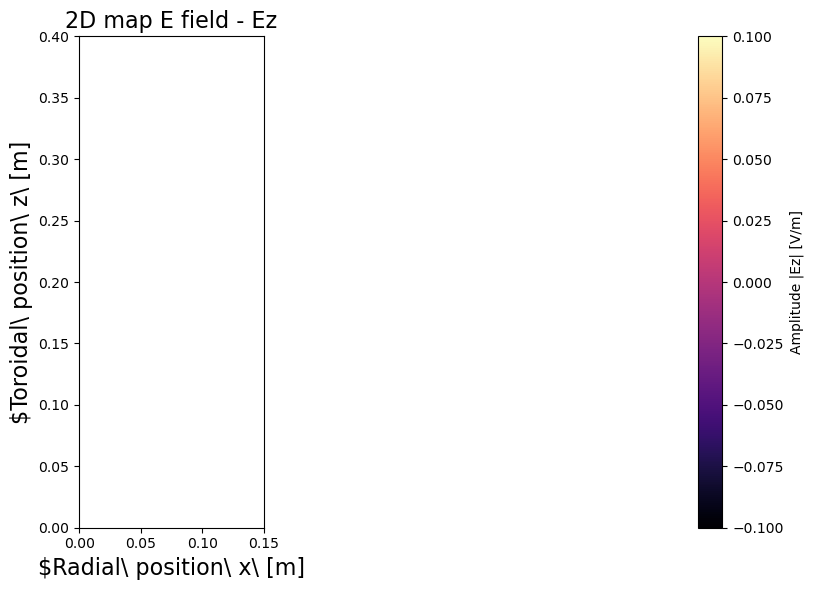

--- Extraction du profil radial à z = 0.2 m ---


TypeError: 'complex' object is not subscriptable

In [4]:
# 3. Post processing
print("--- Post-Processing ---")
my_pp.plot_2d_map(solver, component ='Ez', resolution=10)
z_mid = cfg.DOMAIN['Lz_plasma'] / 2.0
my_pp.plot_radial_profile(solver, z_target=z_mid)